# Crypto Lab 06 — Hard Problems

**CYBR 3570: Applied Cryptography**  
**Topic:** Computational hardness, factoring, and discrete logarithms

## Today's big question

> How can something be easy to verify but hard to find?

This lab connects complexity theory to the cryptographic assumptions behind RSA, Diffie–Hellman, and elliptic curve cryptography.

You will not prove deep results about complexity classes. Instead, you will experiment with growth rates, brute force, factoring, modular groups, and toy discrete logarithms.

## Learning objectives

By the end of this notebook, you should be able to:

1. Distinguish linear, polynomial, exponential, and superpolynomial growth.
2. Explain why exponential search becomes infeasible as input sizes grow.
3. Describe the difference between P, NP, NP-complete, and NP-hard at a high level.
4. Explain why RSA depends on factoring large numbers.
5. Explain why Diffie–Hellman depends on the discrete logarithm problem.
6. Demonstrate, using small examples, how factoring and discrete logs are easy when parameters are too small.
7. Connect hard problems to practical cryptographic engineering decisions.

## Setup

In [1]:
import math
import time
from dataclasses import dataclass
from typing import Optional, List, Tuple

import matplotlib.pyplot as plt

print("Lab 06 setup complete")

Lab 06 setup complete


## Part 1 — Complexity growth

The chapter distinguishes efficient computation from infeasible computation by looking at how runtime grows as the input size grows.

In cryptography, this is essential. A security parameter that is too small can turn a theoretically hard problem into a weekend project.

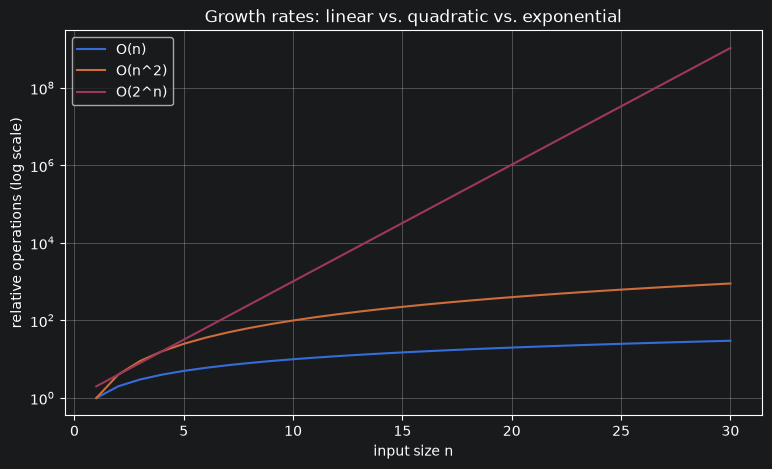

In [2]:
# Run this cell to compare several growth rates.

ns = list(range(1, 31))
linear = [n for n in ns]
quadratic = [n**2 for n in ns]
exponential = [2**n for n in ns]

plt.figure(figsize=(9, 5))
plt.plot(ns, linear, label="O(n)")
plt.plot(ns, quadratic, label="O(n^2)")
plt.plot(ns, exponential, label="O(2^n)")
plt.yscale("log")
plt.xlabel("input size n")
plt.ylabel("relative operations (log scale)")
plt.title("Growth rates: linear vs. quadratic vs. exponential")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

### Exercise 1

In your own words, explain why the y-axis in the previous plot uses a logarithmic scale. What would happen if the plot used a normal linear scale?

Answer: The line 2^n would be off the char, N would appear to be flat.


## Part 2 — Brute-force key search

A secure symmetric cipher should not have an attack much better than brute force. For an n-bit key, a complete search has up to 2^n possible keys.

This exercise estimates how long brute force would take at different rates.

In [3]:
def brute_force_seconds(bits: int, guesses_per_second: float) -> float:
    """Return seconds needed to exhaustively search a bits-bit key space."""
    return (2 ** bits) / guesses_per_second


def human_time(seconds: float) -> str:
    """Convert seconds to a rough human-readable duration."""
    minute = 60
    hour = 60 * minute
    day = 24 * hour
    year = 365.25 * day
    if seconds < minute:
        return f"{seconds:.2f} seconds"
    if seconds < hour:
        return f"{seconds / minute:.2f} minutes"
    if seconds < day:
        return f"{seconds / hour:.2f} hours"
    if seconds < year:
        return f"{seconds / day:.2f} days"
    return f"{seconds / year:.2e} years"

for bits in [32, 40, 56, 64, 80, 128]:
    seconds = brute_force_seconds(bits, guesses_per_second=1e9)
    print(f"{bits:>3}-bit key at 1 billion guesses/sec: {human_time(seconds)}")

 32-bit key at 1 billion guesses/sec: 4.29 seconds
 40-bit key at 1 billion guesses/sec: 18.33 minutes
 56-bit key at 1 billion guesses/sec: 2.28e+00 years
 64-bit key at 1 billion guesses/sec: 5.85e+02 years
 80-bit key at 1 billion guesses/sec: 3.83e+07 years
128-bit key at 1 billion guesses/sec: 1.08e+22 years


### Exercise 2

Change the guess rate from `1e9` to `1e12`. Which key sizes still look weak? Which look infeasible?

In [6]:
# TODO: Repeat the brute-force estimate using 1e12 guesses per second.
# Print results for 32, 40, 56, 64, 80, and 128 bits.

# Your code here
for bits in [32, 40, 56, 64, 80, 128]:
    seconds = brute_force_seconds(bits, guesses_per_second=1e12)
    print(f"{bits:>3}-bit key at 1 trillion guesses/sec: {human_time(seconds)}")

 32-bit key at 1 trillion guesses/sec: 0.00 seconds
 40-bit key at 1 trillion guesses/sec: 1.10 seconds
 56-bit key at 1 trillion guesses/sec: 20.02 hours
 64-bit key at 1 trillion guesses/sec: 213.50 days
 80-bit key at 1 trillion guesses/sec: 3.83e+04 years
128-bit key at 1 trillion guesses/sec: 1.08e+19 years


## Part 3 — P, NP, NP-complete, and NP-hard

This course does not require a formal proof-based understanding of complexity theory. However, you should know what these terms mean well enough to avoid misleading claims such as “RSA is secure because factoring is NP-hard.”

Using the textbook and internet searches, fill in the following table in your own words.

*P* - Problems we can solve in polynomial time on a normal computer. If a break of the cryptosystem is in P, the scheme is not secure.

*NP* - Problems whose yes-answers we can check quickly if someone hands us a witness (e.g., the factors of N).

*NP-Complete* - The “hardest” problems in NP such that if any one of them has a fast algorithm, every problem in NP does.

*NP-Hard* - Worst-Case hardness, but once you have it you can use it to solve the other NP problems easily.

*average-case hardness* - The expected average difficuly of several random inputs; the more inputs, the merrier.

*worst-case hardness* - The hardest possible input may still be incredibly easy.

### Discussion prompt

Why might worst-case hardness be insufficient for cryptography?

Write 3–5 sentences.

Answer = Worst-case hardness only says that some instances of a problem are hard. A cryptosystem generates keys from a specific distribution, so an attacker only has to break those typical instances. An algorithm can fail on a few pathological inputs and still factor almost every RSA modulus we actually use. That is why “this problem is NP-hard” does not imply that the keys we sample are safe as cryptography needs average-case hardness on the distribution the scheme really produces, plus a reduction that connects a break of the scheme to solving that average-case problem.

## Part 4 — Factoring small numbers

RSA uses a modulus of the form `N = p * q`, where `p` and `q` are large primes. Multiplying `p` and `q` is easy. Recovering `p` and `q` from `N` should be infeasible when `p`, `q`, and `N` are large and carefully generated.

We will use simple trial division to factor small numbers. This is intentionally inefficient, but it makes the scaling problem visible.

In [4]:
def trial_division_factor(n: int) -> List[int]:
    """Return a prime factorization of n using simple trial division."""
    factors = []
    divisor = 2
    while divisor * divisor <= n:
        while n % divisor == 0:
            factors.append(divisor)
            n //= divisor
        divisor += 1 if divisor == 2 else 2  # after 2, check odd divisors only
    if n > 1:
        factors.append(n)
    return factors

for n in [123456, 1234567, 8051, 99991 * 100003]:
    start = time.perf_counter()
    factors = trial_division_factor(n)
    elapsed = time.perf_counter() - start
    print(f"{n} = {' * '.join(map(str, factors))}   ({elapsed:.6f} seconds)")

123456 = 2 * 2 * 2 * 2 * 2 * 2 * 3 * 643   (0.000005 seconds)
1234567 = 127 * 9721   (0.000004 seconds)
8051 = 83 * 97   (0.000002 seconds)
9999399973 = 99991 * 100003   (0.003164 seconds)


### Exercise 3

Try factoring products of two primes of increasing size.

Use the sample primes below, then add at least two additional examples of your own. Record when the runtime starts to become noticeable.

In [8]:
prime_pairs = [
    (101, 113),
    (1009, 1013),
    (10007, 10009),
    (1000003, 1000033),
    (51473069, 99746677),
    (541916083, 611604827),
]

for p, q in prime_pairs:
    n = p * q
    start = time.perf_counter()
    factors = trial_division_factor(n)
    elapsed = time.perf_counter() - start
    print(f"N = {n} ({p} * {q})")
    print(f"  factors: {factors}")
    print(f"  time: {elapsed:.6f} seconds")

N = 11413 (101 * 113)
  factors: [101, 113]
  time: 0.000003 seconds
N = 1022117 (1009 * 1013)
  factors: [1009, 1013]
  time: 0.000066 seconds
N = 100160063 (10007 * 10009)
  factors: [10007, 10009]
  time: 0.000175 seconds
N = 1000036000099 (1000003 * 1000033)
  factors: [1000003, 1000033]
  time: 0.018618 seconds
N = 5134267587741713 (51473069 * 99746677)
  factors: [51473069, 99746677]
  time: 1.135744 seconds
N = 331438492191732641 (541916083 * 611604827)
  factors: [541916083, 611604827]
  time: 11.822644 seconds


### Exercise 4

Explain why this toy experiment does **not** mean that real RSA can be broken with trial division.

Your answer should mention at least two of the following:

- size of real RSA moduli,
- carefully chosen primes,
- better factoring algorithms,
- complexity growth,
- why small examples are still useful for learning.

Answer: Real RSA moduli are too large to use trial division on. A modern modulus is typically 2048 or 3072 bits built from 2 chosen primes. The work grows exponentially with the bit length, and even checking a tiny fraction of those candidates is beyond any standard computer.

## Part 5 — Modular groups

The discrete logarithm problem is usually described inside a mathematical group. A common example is the multiplicative group of nonzero integers modulo a prime `p`, written `Z_p*`.

For example, `Z_5* = {1, 2, 3, 4}` under multiplication modulo 5.

In [9]:
def zn_star(p: int) -> List[int]:
    """Return the nonzero elements modulo prime p."""
    return list(range(1, p))


def powers_mod(g: int, p: int) -> List[int]:
    """Return g^1, g^2, ..., g^(p-1) modulo p."""
    return [pow(g, k, p) for k in range(1, p)]

p = 5
for g in zn_star(p):
    print(f"powers of {g} mod {p}: {powers_mod(g, p)}")

powers of 1 mod 5: [1, 1, 1, 1]
powers of 2 mod 5: [2, 4, 3, 1]
powers of 3 mod 5: [3, 4, 2, 1]
powers of 4 mod 5: [4, 1, 4, 1]


### Exercise 5

Find the generators of `Z_7*`.

A generator is an element whose powers produce every nonzero element modulo `p`.

### Worked example for Exercise 5 — Finding generators

Before solving `Z_7*`, work through the same idea with `Z_11*`. A generator must produce **every** nonzero residue modulo 11 when we compute its powers.

The code below compares the set of powers of each candidate `g` with `{1, 2, ..., 10}`. If the sets match, `g` is a generator.


In [10]:
def is_generator_example(g: int, p: int) -> bool:
    residues = {pow(g, k, p) for k in range(1, p)}
    required = set(range(1, p))
    return residues == required

example_p = 11
example_generators = [
    g for g in range(1, example_p)
    if is_generator_example(g, example_p)
]

print(f"Generators of Z_{example_p}*: {example_generators}")
for g in example_generators[:1]:
    print(f"Powers of {g} mod {example_p}: {powers_mod(g, example_p)}")


Generators of Z_11*: [2, 6, 7, 8]
Powers of 2 mod 11: [2, 4, 8, 5, 10, 9, 7, 3, 6, 1]


**What to notice:** a candidate is not a generator merely because its powers look varied. It must visit every nonzero element before repeating. Use the same set-comparison idea to complete Exercise 5 for `p = 7`.


In [12]:
def is_generator(g: int, p: int) -> bool:
    """Return True if g generates Z_p*. Assumes p is prime."""
    residues = {pow(g, k, p) for k in range(1, p)}
    required = set(range(1, p))
    return residues == required

p = 7
generators = []
for g in zn_star(p):
    if is_generator(g, p):
        generators.append(g)

print(f"Generators of Z_{p}*: {generators}")

Generators of Z_7*: [3, 5]


## Part 6 — Brute-forcing a discrete logarithm

The discrete logarithm problem asks:

> Given `g`, `x`, and `p`, find `y` such that `g^y = x mod p`.

For small groups, brute force is easy. For cryptographic groups, it should be infeasible.

In [13]:
def discrete_log_bruteforce(g: int, x: int, p: int) -> Optional[int]:
    """Find y such that g^y = x mod p by brute force, or return None."""
    for y in range(0, p - 1):
        if pow(g, y, p) == x:
            return y
    return None

p = 23
g = 5
secret_y = 13
x = pow(g, secret_y, p)

found_y = discrete_log_bruteforce(g, x, p)
print(f"Given g={g}, x={x}, p={p}")
print(f"Recovered y = {found_y}")

Given g=5, x=21, p=23
Recovered y = 13


### Exercise 6

Use `discrete_log_bruteforce()` to solve at least three small discrete logarithm problems.

Then write a short explanation of why the same strategy is not practical for cryptographic group sizes.

Suppose `p = 17`, `g = 3`, and a public value is `x = 5`. We want to find `y` such that `3^y ≡ 5 (mod 17)`.

For a tiny group, we can simply try exponents one at a time.


**Why this stops scaling:** brute force may require trying a number of exponents proportional to the group size. Tiny classroom groups contain only a few dozen possibilities; cryptographic groups are intentionally enormous, so enumerating possible exponents becomes infeasible.


In [ ]:
# TODO: Create and solve at least three small discrete logarithm examples.

examples = [
    (25,5,13),
    (17,3,5)
]

for p, g, y in examples:
    x = pow(g, y, p)
    recovered = discrete_log_bruteforce(g, x, p)
    print(f"p={p}, g={g}, x={x}, expected y={y}, recovered y={recovered}")


Explain how this works:

## Part 7 — A toy Diffie–Hellman key exchange

Diffie–Hellman key agreement lets two parties establish a shared secret over an insecure channel.

This toy version uses tiny parameters and is **not secure**. It exists only to show the algebraic structure.

In [14]:
# Toy Diffie-Hellman example
p = 23
# For p = 23, 5 is a generator of a large subgroup in this toy setting.
g = 5

alice_secret = 6
bob_secret = 15

alice_public = pow(g, alice_secret, p)
bob_public = pow(g, bob_secret, p)

alice_shared = pow(bob_public, alice_secret, p)
bob_shared = pow(alice_public, bob_secret, p)

print(f"public p = {p}, g = {g}")
print(f"Alice public value: {alice_public}")
print(f"Bob public value:   {bob_public}")
print(f"Alice shared secret: {alice_shared}")
print(f"Bob shared secret:   {bob_shared}")
print(f"Shared values match? {alice_shared == bob_shared}")

public p = 23, g = 5
Alice public value: 8
Bob public value:   19
Alice shared secret: 2
Bob shared secret:   2
Shared values match? True


### Worked example for Exercise 7 — Breaking toy Diffie–Hellman

Here is a separate toy exchange so you can see the attack before applying it to the exercise above.

We use `p = 29`, `g = 2`, Alice secret `a = 7`, and Bob secret `b = 11`. An eavesdropper sees only `p`, `g`, and the two public values. Because the group is tiny, the attacker can brute-force Alice's discrete logarithm and then compute the same shared secret.


In [15]:
example_p = 29
example_g = 2
example_alice_secret = 7
example_bob_secret = 11

example_alice_public = pow(example_g, example_alice_secret, example_p)
example_bob_public = pow(example_g, example_bob_secret, example_p)

print("Public information:")
print("p =", example_p, "g =", example_g)
print("Alice public =", example_alice_public)
print("Bob public   =", example_bob_public)

# Attacker solves g^a = Alice_public (mod p).
recovered_a = discrete_log_bruteforce(
    example_g, example_alice_public, example_p
)

# Once a is known, Bob's public value reveals the shared secret.
attacker_secret = pow(example_bob_public, recovered_a, example_p)
actual_secret = pow(example_bob_public, example_alice_secret, example_p)

print("Recovered Alice secret =", recovered_a)
print("Attacker shared secret  =", attacker_secret)
print("Actual shared secret    =", actual_secret)
print("Attack succeeded?", attacker_secret == actual_secret)


Public information:
p = 29 g = 2
Alice public = 12
Bob public   = 18
Recovered Alice secret = 7
Attacker shared secret  = 17
Actual shared secret    = 17
Attack succeeded? True


### Exercise 7

In the toy example above, an attacker sees `p`, `g`, `alice_public`, and `bob_public`.

Use brute force to recover Alice's secret exponent from her public value. Then compute the shared secret as the attacker.

In [16]:
# TODO: Recover Alice's secret using discrete_log_bruteforce.
# Then use Bob's public value to compute the shared secret.

attacker_recovered_alice_secret = None
attacker_shared_secret = None

print("Recovered Alice secret:", attacker_recovered_alice_secret)
print("Attacker shared secret:", attacker_shared_secret)

Recovered Alice secret: None
Attacker shared secret: None


### Reflection

Why does this attack work in the toy example but not in real Diffie–Hellman with secure parameters?

Reflection: P and G are way too small to be securable.

## Part 8 — Engineering checkpoint

This chapter is a bridge from symmetric cryptography to public-key cryptography. It also reinforces one of the course's central themes:

> Security depends on algorithms, assumptions, parameters, and implementations.

Answer the following.

- Why is '128-bit RSA' not equivalent to '128-bit security'?"

RSA means a 128-bit modulus, not 2^128 work to brute-force the key. The modulus is incredibly easy to factor.

- Why is weak Diffie-Hellman parameter negotiation dangerous?

If a protocol lets the peer choose the group, an attacker can force a small or well-known modulus. Discrete log in that group can be precomputed once and then used to break many sessions.

- What should a security review check besides the algorithm name?

Parameter and Key sizes.
How keys and nonces are generated.
Mode and nonce rules.
Peer must not be allowed to downgrade to weak groups, old padding, or export parameters.

## Submission checklist

Before submitting, make sure you have:

- [ ] Completed all written responses.
- [ ] Implemented the missing code exercises.
- [ ] Run the notebook from top to bottom without errors.

## Final reflection

Return to today's big question:

> How can something be easy to verify but hard to find?

Explain the answer using either factoring or discrete logarithms as your example.

Reflection: